## Bilinear interpolation

**Bilinear** interpolation resamples data onto a regular pixel grid by computing a weighted average of the four surrounding source values for each output pixel. The result is a smooth, continuous-looking field with no visible cell boundaries — well suited to filled contours and shaded plots where a visually clean output is desired.

Use `Bilinear` when:
- your source data is on a **regular lat/lon** (or other rectilinear) grid, and
- you want **smooth, interpolated** rendering rather than sharp grid-cell edges.

For unstructured or native HEALPix/reduced-Gaussian grids, combine `Bilinear` with `Regrid` via a `Chain` (covered in the [Regrid notebook](resampling-regrid.ipynb)).

### Example: 2 m temperature over Europe

We will use a sample GRIB file containing 2 m temperature on a regular lat/lon grid.

In [1]:
import earthkit.data as ekd

import earthkit.plots as ekp

data = ekd.from_source("sample", "test.grib").to_fieldlist()
data.ls()

test.grib:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,2t,2020-05-13 12:00:00,2020-05-13 12:00:00,0 days,0,surface,0,regular_ll
1,msl,2020-05-13 12:00:00,2020-05-13 12:00:00,0 days,0,surface,0,regular_ll


### Default pixel count

Calling `Bilinear()` with no arguments uses **1000 × 1000 pixels** — a good default for most maps. The pixel grid is always aligned with the map's coordinate reference system (CRS), not the source grid.

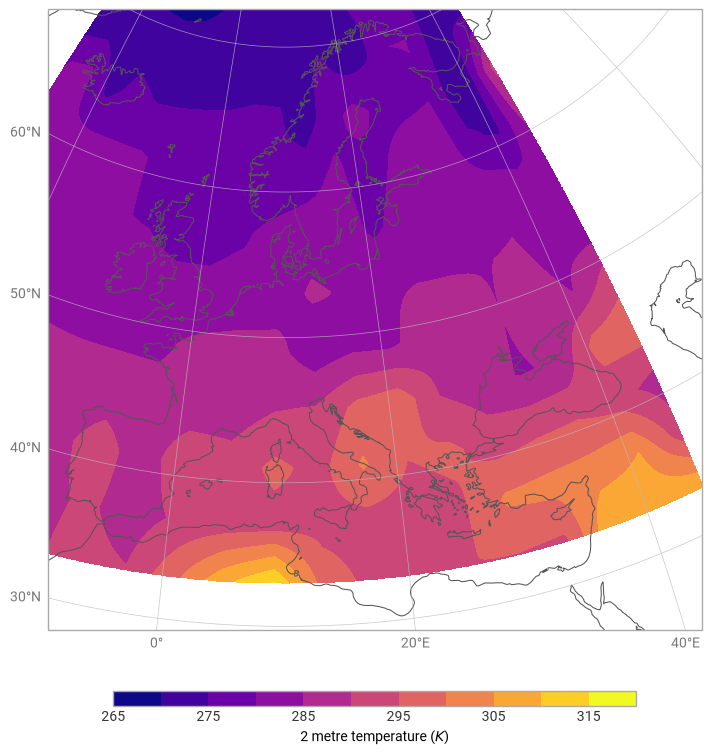

In [2]:
from earthkit.plots.resample import Bilinear

chart = ekp.Map(domain="Europe")

chart.contourf(data, resample=Bilinear())

chart.coastlines()
chart.gridlines()
chart.legend()

chart.show()

### Controlling the pixel count

Pass a single integer to set both `nx` and `ny` to the same value, or use `nx`/`ny` keyword arguments to specify them independently. Lowering the count reveals the individual pixels; raising it gives a finer result.

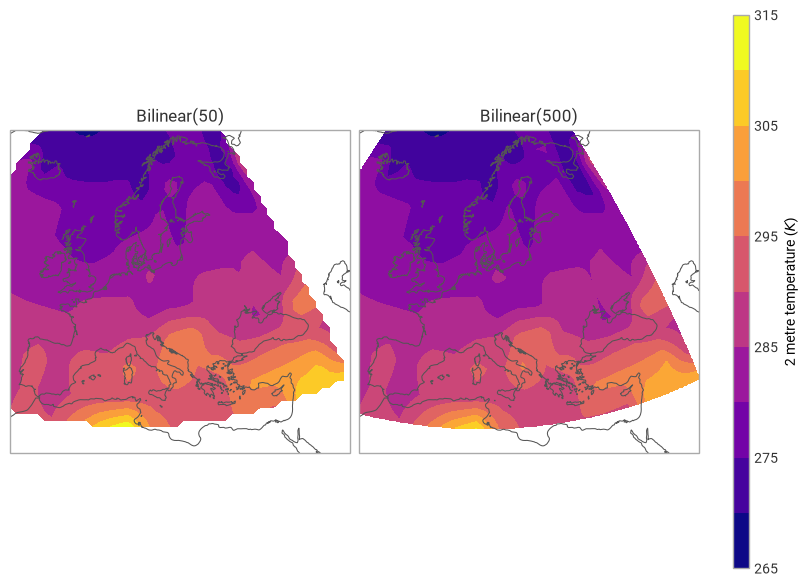

In [3]:
figure = ekp.Figure(rows=1, columns=2, domain="Europe")

# Coarse — individual pixels are visible
ax = figure.add_map()
ax.contourf(data, resample=Bilinear(50))
ax.title("Bilinear(50)")

# Fine — very smooth appearance
ax = figure.add_map()
ax.contourf(data, resample=Bilinear(500))
ax.title("Bilinear(500)")

figure.coastlines()
figure.legend(location="right")

figure.show()

### Resolution-based specification

Instead of a fixed pixel count, you can specify the **pixel spacing in degrees** using `Bilinear.at_resolution(dx)`. The pixel count then adapts automatically to the map extent — useful when you want consistent detail at different zoom levels.

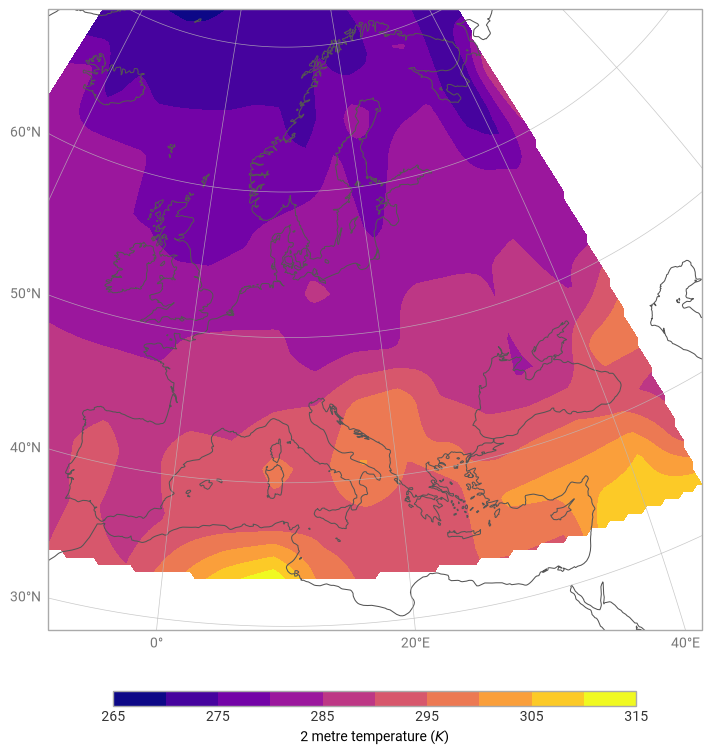

In [4]:
chart = ekp.Map(domain="Europe")

# One output pixel per 0.5 degrees
chart.contourf(data, resample=Bilinear.at_resolution(0.5))

chart.coastlines()
chart.gridlines()
chart.legend()

chart.show()

<div class="alert alert-block alert-info">
<strong>NOTE:</strong> Unlike <code>Subsample</code>, <code>Bilinear</code> can <em>upsample</em> — you can request more pixels than source grid points. The interpolated values are estimated from the surrounding source data.
</div>